In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

train = pd.read_csv('/content/KDDTrain+.txt', header=None)
test = pd.read_csv('/content/KDDTest+.txt', header=None)

print(train.shape)
print(test.shape)

(125973, 43)
(22544, 43)


In [ ]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       125973 non-null  int64  
 1   1       125973 non-null  object 
 2   2       125973 non-null  object 
 3   3       125973 non-null  object 
 4   4       125973 non-null  int64  
 5   5       125973 non-null  int64  
 6   6       125973 non-null  int64  
 7   7       125973 non-null  int64  
 8   8       125973 non-null  int64  
 9   9       125973 non-null  int64  
 10  10      125973 non-null  int64  
 11  11      125973 non-null  int64  
 12  12      125973 non-null  int64  
 13  13      125973 non-null  int64  
 14  14      125973 non-null  int64  
 15  15      125973 non-null  int64  
 16  16      125973 non-null  int64  
 17  17      125973 non-null  int64  
 18  18      125973 non-null  int64  
 19  19      125973 non-null  int64  
 20  20      125973 non-null  int64  
 21  21      12

In [ ]:
train[41].value_counts().head(20)

,count
41,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931
smurf,2646
nmap,1493
back,956
teardrop,892


In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in [1,2,3]:
    le = LabelEncoder()

    train[col] = le.fit_transform(train[col])
    test[col] = le.fit_transform(test[col])

In [ ]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,1,24,9,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,1,24,9,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
attack_mapping = {

    'normal':'Normal',

    'back':'DoS',
    'land':'DoS',
    'neptune':'DoS',
    'pod':'DoS',
    'smurf':'DoS',
    'teardrop':'DoS',

    'ipsweep':'Probe',
    'nmap':'Probe',
    'portsweep':'Probe',
    'satan':'Probe',

    'ftp_write':'R2L',
    'guess_passwd':'R2L',
    'imap':'R2L',
    'multihop':'R2L',
    'phf':'R2L',
    'spy':'R2L',
    'warezclient':'R2L',
    'warezmaster':'R2L',

    'buffer_overflow':'U2R',
    'loadmodule':'U2R',
    'perl':'U2R',
    'rootkit':'U2R'
}

In [ ]:
train[41] = train[41].map(attack_mapping)
test[41] = test[41].map(attack_mapping)

In [ ]:
train = train.dropna()
test = test.dropna()

In [ ]:
train[41].value_counts()

,count
41,
Normal,67343
DoS,45927
Probe,11656
R2L,995
U2R,52


In [ ]:
X_train = train.iloc[:, :-2]
y_train = train.iloc[:, -2]

X_test = test.iloc[:, :-2]
y_test = test.iloc[:, -2]

In [ ]:
print(X_train.shape)
print(y_train.shape)

(125973, 41)
(125973,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test,pred)

print(acc)

0.8713951261040758


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         DoS       0.99      0.99      0.99      5741
      Normal       0.81      0.97      0.89      9711
       Probe       0.85      1.00      0.92      1106
         R2L       1.00      0.04      0.09      2199
         U2R       1.00      0.03      0.05        37

    accuracy                           0.87     18794
   macro avg       0.93      0.61      0.59     18794
weighted avg       0.89      0.87      0.83     18794



In [ ]:
print(train.shape)
print(test.shape)

(125973, 43)
(18794, 43)


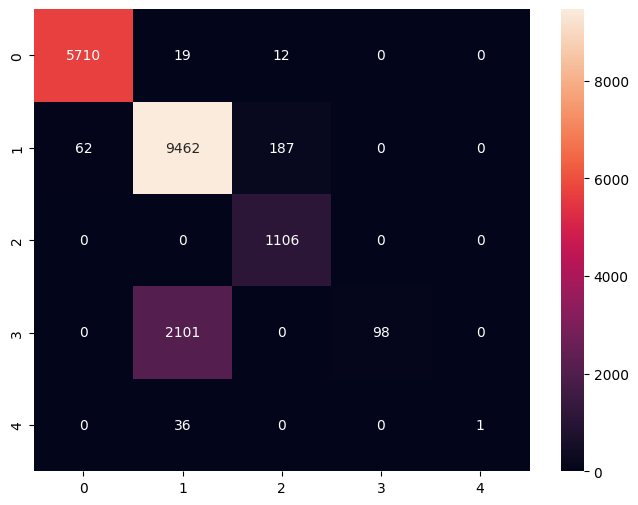

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d')
plt.show()